In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [1]:
import pandas as pd
import os

csv_path = "/kaggle/input/vinbigdata-chest-xray-abnormalities-detection/train.csv"
df = pd.read_csv(csv_path)

df.head()


,image_id,class_name,class_id,rad_id,x_min,y_min,x_max,y_max
0,50a418190bc3fb1ef1633bf9678929b3,No finding,14,R11,NaN,NaN,NaN,NaN
1,21a10246a5ec7af151081d0cd6d65dc9,No finding,14,R7,NaN,NaN,NaN,NaN
2,9a5094b2563a1ef3ff50dc5c7ff71345,Cardiomegaly,3,R10,691.0,1375.0,1653.0,1831.0
3,051132a778e61a86eb147c7c6f564dfe,Aortic enlargement,0,R10,1264.0,743.0,1611.0,1019.0
4,063319de25ce7edb9b1c6b8881290140,No finding,14,R10,NaN,NaN,NaN,NaN


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 67914 entries, 0 to 67913
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   image_id    67914 non-null  object 
 1   class_name  67914 non-null  object 
 2   class_id    67914 non-null  int64  
 3   rad_id      67914 non-null  object 
 4   x_min       36096 non-null  float64
 5   y_min       36096 non-null  float64
 6   x_max       36096 non-null  float64
 7   y_max       36096 non-null  float64
dtypes: float64(4), int64(1), object(3)
memory usage: 4.1+ MB


In [3]:
df.describe()

,class_id,x_min,y_min,x_max,y_max
count,67914.000000,36096.000000,36096.000000,36096.000000,36096.000000
mean,9.979312,1051.332696,1065.262051,1492.269337,1456.660489
std,5.036494,565.838078,552.925133,595.384126,581.134138
min,0.000000,0.000000,0.000000,68.000000,103.000000
25%,7.000000,602.000000,627.000000,1010.000000,1009.000000
50%,13.000000,1014.500000,935.000000,1567.000000,1411.000000
75%,14.000000,1457.000000,1471.000000,1947.000000,1911.000000
max,14.000000,2934.000000,3133.000000,3131.000000,3384.000000


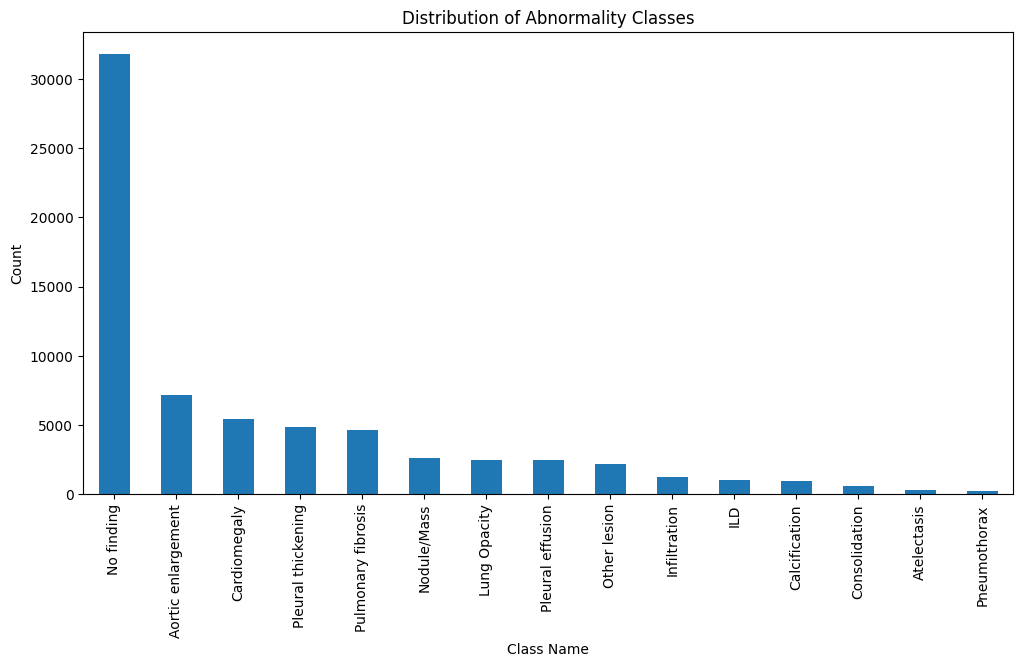

In [4]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
df['class_name'].value_counts().plot(kind='bar')
plt.title("Distribution of Abnormality Classes")
plt.xlabel("Class Name")
plt.ylabel("Count")
plt.xticks(rotation=90)
plt.show()

In [1]:
import os
import pydicom
from PIL import Image
from tqdm import tqdm

DATA_DIR = "/kaggle/input/vinbigdata-chest-xray-abnormalities-detection/train"
OUTPUT_DIR = "/kaggle/working/converted_png"

os.makedirs(OUTPUT_DIR, exist_ok=True)

# Get only the first 200 DICOM files (fast)
all_files = [f for f in os.listdir(DATA_DIR) if f.endswith(".dicom")]
files = all_files[:200]

print("Total DICOM files found:", len(all_files))
print("Converting only:", len(files), "files")

count = 0

for fname in tqdm(files, total=len(files)):
    dcm_path = os.path.join(DATA_DIR, fname)
    try:
        ds = pydicom.dcmread(dcm_path)
        img = ds.pixel_array

        img_pil = Image.fromarray(img)

        png_name = fname.replace(".dicom", ".png")
        png_path = os.path.join(OUTPUT_DIR, png_name)
        img_pil.save(png_path)

        count += 1
    except Exception as e:
        print("Error processing:", fname, e)

print("Conversion completed.")
print("Total images converted:", count)

Total DICOM files found: 15000
Converting only: 200 files


100%|██████████| 200/200 [13:26<00:00,  4.03s/it]

Conversion completed.
Total images converted: 200


Number of converted images: 200
Showing sample image: c26185210303f6c638a4ac60e635df21.png


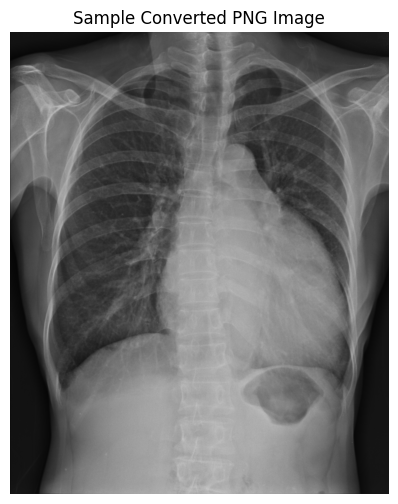

In [2]:
import os
import matplotlib.pyplot as plt
from PIL import Image

# Path
png_dir = "/kaggle/working/converted_png"

files = os.listdir(png_dir)
print("Number of converted images:", len(files))

sample_file = files[0]
print("Showing sample image:", sample_file)

# Open and display the image
img_path = os.path.join(png_dir, sample_file)
img = Image.open(img_path)

plt.figure(figsize=(6, 6))
plt.imshow(img, cmap="gray")
plt.title("Sample Converted PNG Image")
plt.axis("off")
plt.show()